#  full_dataset_with_captions_0208.json analysis

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

sns.set_style('whitegrid')

## Загрузка данных

In [2]:
file_path = '/home/vitalymorozov/PycharmProjects/horde-common/user/vitaly_m/KazDataset_Analysis/full_dataset_with_captions_0308.json'

with open(file_path, 'r') as f:
    data = json.load(f)

## Извлечение статистики

In [3]:
records = []

for item in tqdm(data):
    info = item.get('info', {})

    content_properties = info.get('content_properties', {})
    text_properties = info.get('text_properties', {})
    task_suitability = info.get('task_suitability', {})

    record = {
        'quality': content_properties.get('quality', 'unknown'),
        'primary_subject': content_properties.get('primary_subject', 'unknown'),
        'object_count': content_properties.get('object_count', 0),
        'human_presence': content_properties.get('human_presence', 'unknown'),
        'face_visibility': content_properties.get('face_visibility', 'unknown'),
        'contains_text': text_properties.get('contains_text', False),
        'is_suitable_for_ocr': text_properties.get('is_suitable_for_ocr', False),
        'text_type': text_properties.get('text_type', 'unknown'),
        'is_suitable_for_counting': task_suitability.get('is_suitable_for_counting', False),
        'is_suitable_for_reasoning': task_suitability.get('is_suitable_for_reasoning', False),
        'is_suitable_for_multi_step_instruction': task_suitability.get('is_suitable_for_multi_step_instruction', False),
        'vqa_count': len(item.get('vqa', []))
    }

    records.append(record)

df = pd.DataFrame(records)


100%|██████████| 56875/56875 [00:00<00:00, 378266.37it/s]


## Visualization

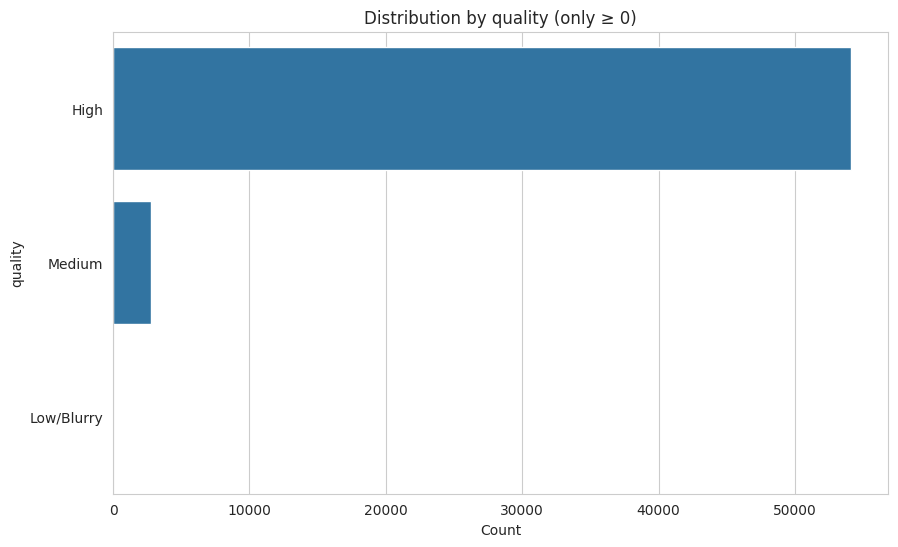

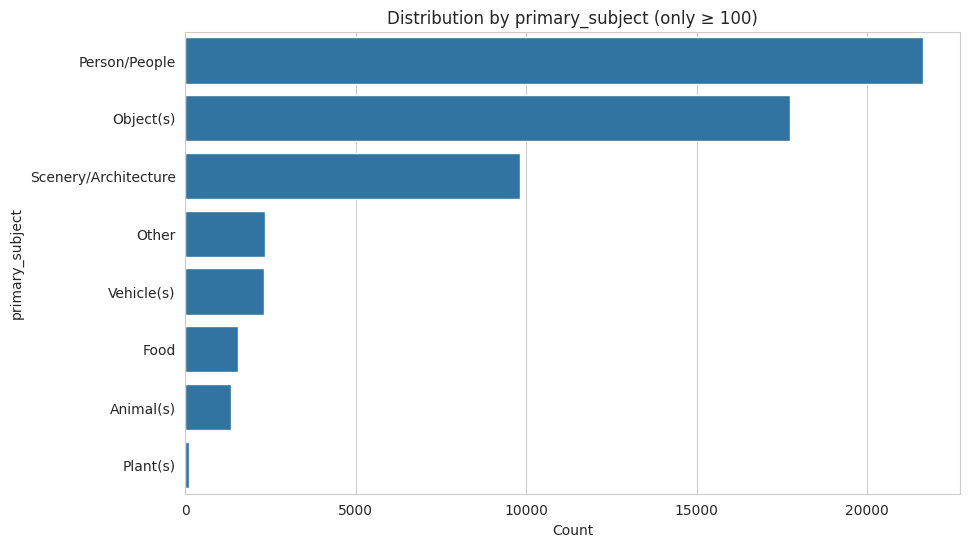

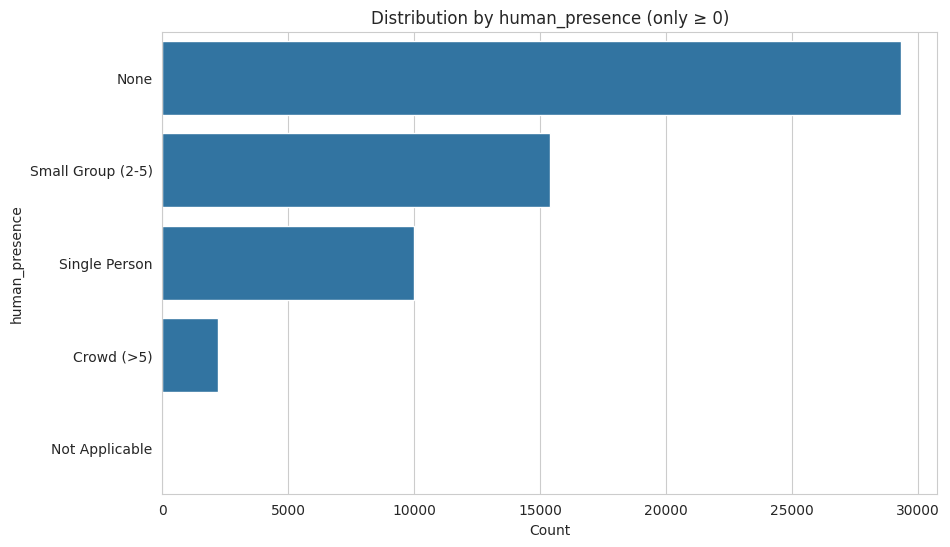

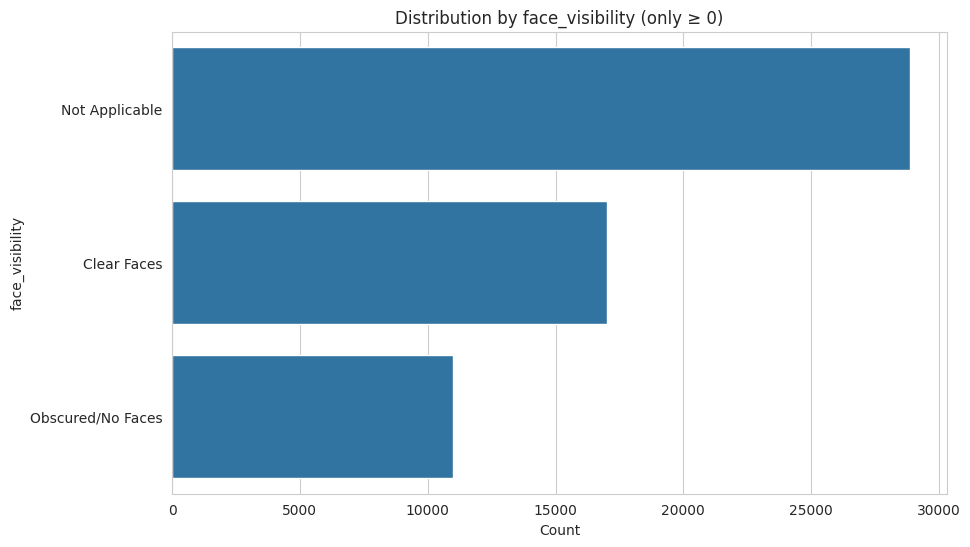

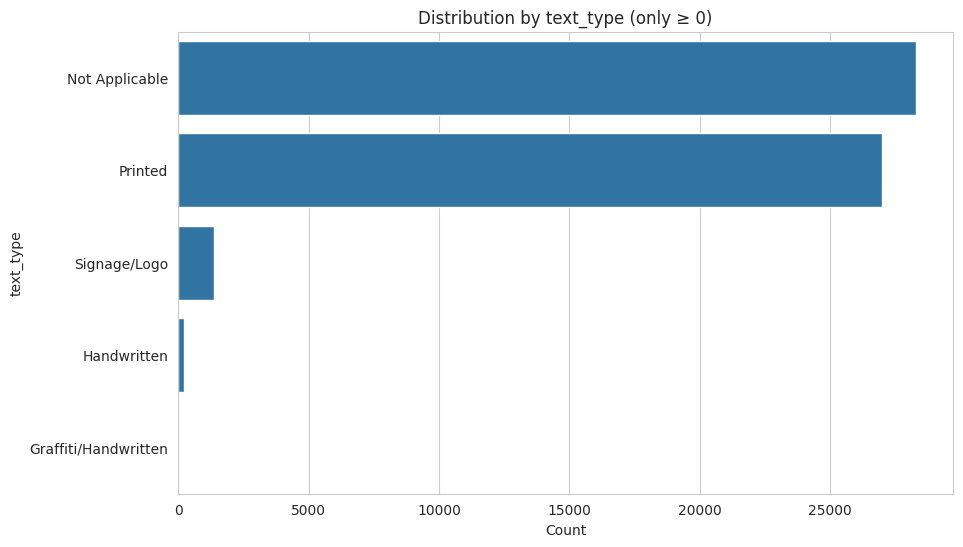

In [4]:
def plot_categorical_distribution(df, column_name, min_count=0):
    value_counts = df[column_name].value_counts()
    filtered_values = value_counts[value_counts >= min_count]

    plt.figure(figsize=(10, 6))
    sns.countplot(
        y=df[df[column_name].isin(filtered_values.index)][column_name],
        order=filtered_values.index
    )
    plt.title(f'Distribution by {column_name} (only ≥ {min_count})')
    plt.xlabel('Count')
    plt.ylabel(column_name)
    plt.show()


plot_categorical_distribution(df, 'quality')
plot_categorical_distribution(df, 'primary_subject', min_count=100)
plot_categorical_distribution(df, 'human_presence')
plot_categorical_distribution(df, 'face_visibility')
plot_categorical_distribution(df, 'text_type')

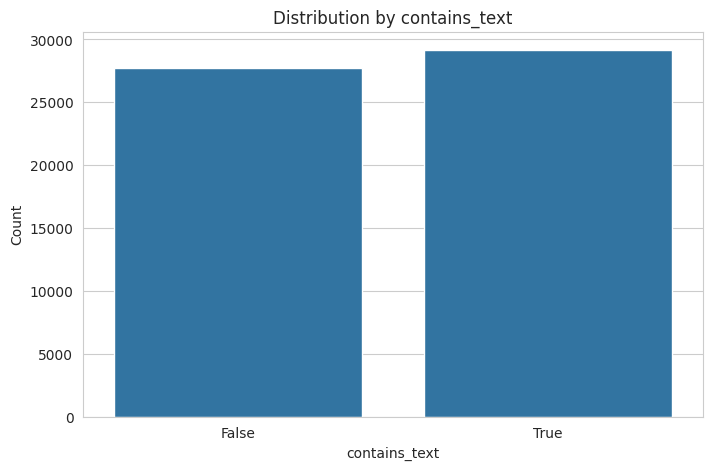

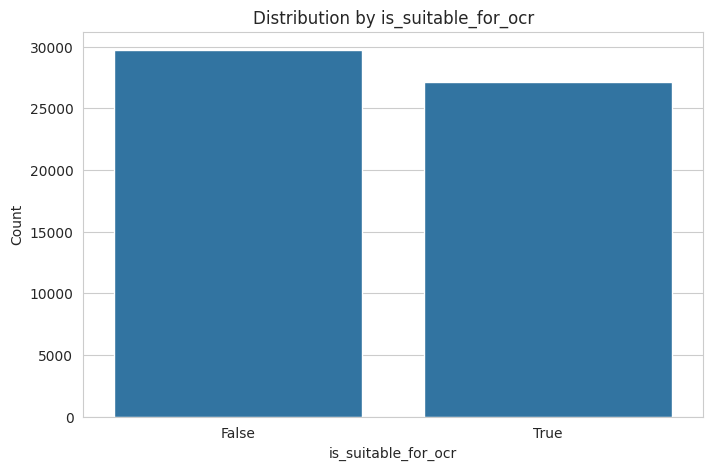

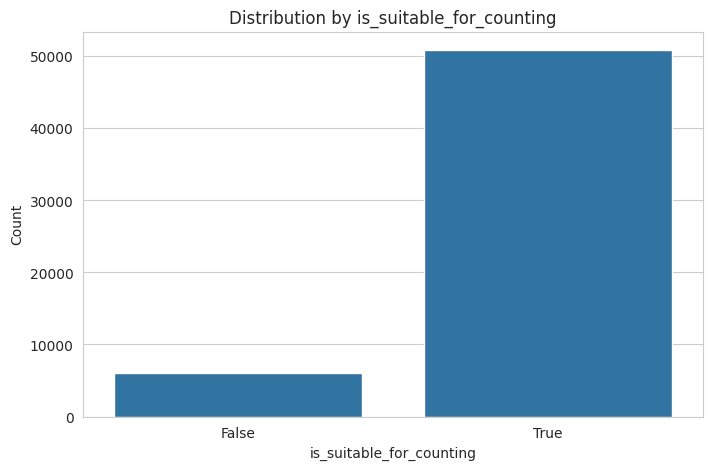

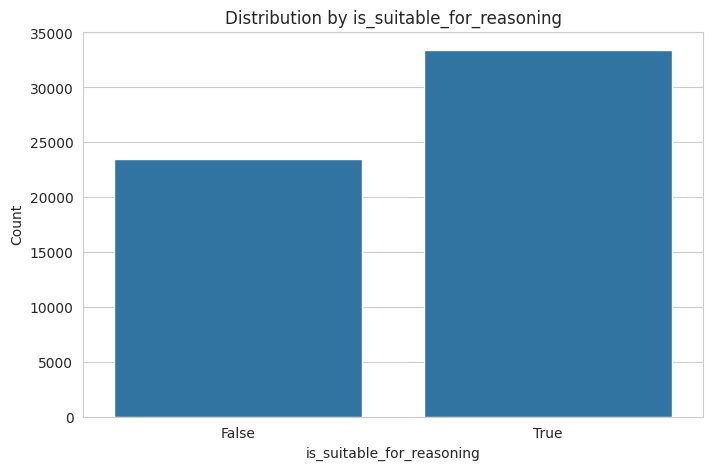

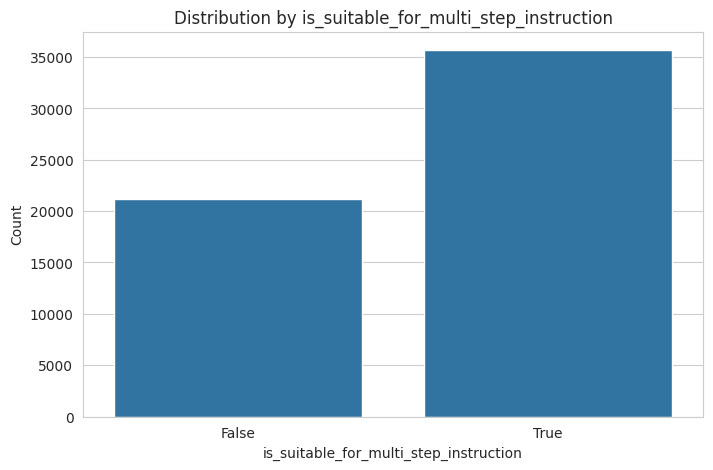

In [5]:
def plot_boolean_distribution(df, column_name):
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df[column_name])
    plt.title(f'Distribution by {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Count')
    plt.show()

plot_boolean_distribution(df, 'contains_text')
plot_boolean_distribution(df, 'is_suitable_for_ocr')
plot_boolean_distribution(df, 'is_suitable_for_counting')
plot_boolean_distribution(df, 'is_suitable_for_reasoning')
plot_boolean_distribution(df, 'is_suitable_for_multi_step_instruction')

## By tables

In [6]:
# Категориальные колонки
categorical_columns = ['quality', 'primary_subject', 'human_presence', 'face_visibility', 'text_type']
for col in categorical_columns:
    display(df[col].value_counts().rename_axis(col).reset_index(name='count'))

# Булевы колонки
boolean_columns = [
    'contains_text',
    'is_suitable_for_ocr',
    'is_suitable_for_counting',
    'is_suitable_for_reasoning',
    'is_suitable_for_multi_step_instruction',
    'object_count',
    'vqa_count',
]
for col in boolean_columns:
    display(df[col].value_counts().rename_axis(col).reset_index(name='count'))

# Числовые колонки
numerical_columns = ['object_count', 'vqa_count']
display(df[numerical_columns].describe().T)


,quality,count
0,High,54116
1,Medium,2753
2,Low/Blurry,6


,primary_subject,count
0,Person/People,21653
1,Object(s),17749
2,Scenery/Architecture,9814
3,Other,2346
4,Vehicle(s),2310
5,Food,1557
6,Animal(s),1342
7,Plant(s),104


,human_presence,count
0,None,29294
1,Small Group (2-5),15376
2,Single Person,9992
3,Crowd (>5),2212
4,Not Applicable,1


,face_visibility,count
0,Not Applicable,28870
1,Clear Faces,17001
2,Obscured/No Faces,11004


,text_type,count
0,Not Applicable,28297
1,Printed,26988
2,Signage/Logo,1381
3,Handwritten,208
4,Graffiti/Handwritten,1


...

,is_suitable_for_reasoning,count
0,True,33409
1,False,23466


,is_suitable_for_multi_step_instruction,count
0,True,35678
1,False,21197


,object_count,count
0,1,14729
1,2,7265
2,3,5503
3,10,3444
4,5,3282
...,...,...
88,98,1
89,61,1
90,104,1
91,230,1


,vqa_count,count
0,3,56873
1,2,2


,count,mean,std,min,25%,50%,75%,max
object_count,56875.0,9.440686,46.962233,0.0,1.0,4.0,10.0,5000.0
vqa_count,56875.0,2.999965,0.005930,2.0,3.0,3.0,3.0,3.0
